In [2]:
#Error correction model (EC) used for only 2 timeseries but
# VECTOR Error Correction model (VEC) used for more than 2 timeseries
#VEC and VAR(p) are rekated to each other only difference is VEC have ERROR CORRECTION TERM.

In [11]:
import pandas as pd
import polars as pl
import yfinance as yf


class TimeSeriesDataLoader:

    def __init__(self):
        self.series_dict = {}

    def add_from_yfinance(
        self, ticker: str, name: str, period: str = "5d", interval: str = "1m"
    ):
        data = yf.download(ticker, period=period, interval=interval, progress=False)

        if data.empty:
            print(
                f"⚠️ WARNING: '{ticker}' returned NO data! Check period/interval parameters."
            )
            return self

        # Extract Close price and handle MultiIndex if returned by yfinance
        if isinstance(data.columns, pd.MultiIndex):
            s = data["Close"][ticker]
        else:
            s = data["Close"]

        s.name = name
        s = s.dropna()
        # Remove timezone info for clean cross-asset joining
        s.index = pd.to_datetime(s.index).tz_localize(None)

        self.series_dict[name] = s
        print(f"Loaded '{name}' ({ticker}): {len(s)} rows")
        return self

    def build_dataset(self, resample_freq: str = "1min") -> pd.DataFrame:
        if not self.series_dict:
            raise ValueError("No time series added!")

        # Combine all series using outer join to preserve timestamps
        df = pd.concat(self.series_dict.values(), axis=1)

        # Standardize grid frequency if specified
        if resample_freq:
            df = df.resample(resample_freq).last()

        # Forward fill and backward fill missing values created by non-overlapping markets
        df = df.ffill().bfill()

        # Drop any remaining unfillable rows
        df = df.dropna()
        return df


# --- RE-RUN CELL 1 ---
loader = TimeSeriesDataLoader()

# For 1-minute intraday data (max lookback on yfinance is 7d)
loader.add_from_yfinance("HDFCBANK.NS", name="HDFCBANK.NS", period="5d", interval="1m")
loader.add_from_yfinance("ICICIBANK.NS", name="ICICIBANK.NS", period="5d", interval="1m")
loader.add_from_yfinance("AXISBANK.NS", name="AXISBANK.NS", period="5d", interval="1m")

# Build dataset (use '1min' for 1-minute data, or None to keep original timestamps)
data = loader.build_dataset(resample_freq="1min")

# Invert USDCAD if present
if "USDCAD" in data.columns:
    data["CADUSD"] = 1 / data["USDCAD"]
    data = data.drop(columns=["USDCAD"])

print(f"\nFinal cleaned dataset shape: {data.shape}")

C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_30304\171304133.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)


Loaded 'HDFCBANK.NS' (HDFCBANK.NS): 1805 rows


C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_30304\171304133.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)


Loaded 'ICICIBANK.NS' (ICICIBANK.NS): 1803 rows


C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_30304\171304133.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)


Loaded 'AXISBANK.NS' (AXISBANK.NS): 1805 rows

Final cleaned dataset shape: (9001, 3)


In [12]:
def run_fast_adf(df: pd.DataFrame):
    print("=== ADF Test (Levels) ===")
    for col in df.columns:
        series = df[col].dropna()

        # Check if column is constant (all values identical or standard deviation is 0)
        if series.nunique() <= 1 or series.std() == 0:
            print(f"{col:10s} | SKIPPED (Column contains constant/zero-variance values)")
            continue

        res = adfuller(series, maxlag=5)
        print(
            f"{col:10s} | Stat: {res[0]:.4f} | p-val: {res[1]:.4f} | Stationary: {res[1] < 0.05}"
        )

    print("\n=== ADF Test (First Differences) ===")
    df_diff = df.diff().dropna()
    for col in df_diff.columns:
        series_diff = df_diff[col].dropna()

        # Check if differenced series is constant
        if series_diff.nunique() <= 1 or series_diff.std() == 0:
            print(f"{col:10s} | SKIPPED (Differenced column contains constant values)")
            continue

        res = adfuller(series_diff, maxlag=5)
        print(
            f"{col:10s} | Stat: {res[0]:.4f} | p-val: {res[1]:.4f} | Stationary: {res[1] < 0.05}"
        )


run_fast_adf(data)

=== ADF Test (Levels) ===
HDFCBANK.NS | Stat: -3.5829 | p-val: 0.0061 | Stationary: True
ICICIBANK.NS | Stat: -5.1930 | p-val: 0.0000 | Stationary: True
AXISBANK.NS | Stat: 0.7267 | p-val: 0.9904 | Stationary: False

=== ADF Test (First Differences) ===
HDFCBANK.NS | Stat: -56.5088 | p-val: 0.0000 | Stationary: True
ICICIBANK.NS | Stat: -39.6028 | p-val: 0.0000 | Stationary: True
AXISBANK.NS | Stat: -38.5734 | p-val: 0.0000 | Stationary: True


In [13]:
# Calculate safe maximum lag dynamically based on data size
# Rule of thumb: maxlags should not exceed (nobs - 1) / (n_variables + 1)
n_obs, n_vars = data.shape
max_possible_lags = max(1, int((n_obs - 1) / (n_vars + 1)))

# Cap at 15 or max_possible_lags (whichever is smaller)
safe_maxlags = min(15, max_possible_lags - 1)

print(f"Data shape: {n_obs} rows, {n_vars} variables")
print(f"Using safe maxlags = {safe_maxlags}")

# Fit VAR model
var_model = VAR(data)
lag_selection = var_model.select_order(maxlags=safe_maxlags)

# Extract optimal lag
var_lag_p = lag_selection.aic
k_ar_diff = max(1, var_lag_p - 1)

print(lag_selection.summary())
print(f"\nSelected VAR Lag (p): {var_lag_p}")
print(f"Set VECM Difference Lag (k_ar_diff): {k_ar_diff}")

Data shape: 9001 rows, 3 variables
Using safe maxlags = 15
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.05       10.05   2.312e+04       10.05
1       -7.470      -7.460   0.0005701      -7.466
2       -7.529      -7.513   0.0005371      -7.524
3       -7.542      -7.518   0.0005305      -7.534
4       -7.546      -7.515   0.0005282      -7.536
5       -7.561     -7.523*   0.0005202      -7.548
6       -7.562      -7.517   0.0005196      -7.547
7       -7.569      -7.517   0.0005161      -7.551
8       -7.573      -7.514   0.0005141      -7.553
9       -7.577      -7.511   0.0005120      -7.555
10      -7.584      -7.510   0.0005087      -7.559
11      -7.584      -7.503   0.0005087      -7.556
12      -7.594      -7.506   0.0005035      -7.564
13      -7.599      -7.504   0.0005009      -7.567
14      -7.606      -7.504   0.0004975      -7.571
15     -7.618*      -7.

In [14]:
# Runs on any arbitrary number of columns
johansen_res = coint_johansen(data, det_order=0, k_ar_diff=k_ar_diff)

num_assets = data.shape[1]

print("=== JOHANSEN TRACE TEST ===")
for i in range(num_assets):
    stat = johansen_res.lr1[i]
    cv = johansen_res.cvt[i, 1]  # 5% critical value
    print(
        f"r <= {i}: Stat = {stat:.2f} | 5% CV = {cv:.2f} | Cointegrated: {stat > cv}"
    )

print("\n=== JOHANSEN MAX EIGENVALUE TEST ===")
for i in range(num_assets):
    stat = johansen_res.lr2[i]
    cv = johansen_res.cvm[i, 1]  # 5% critical value
    print(
        f"r = {i}: Stat = {stat:.2f} | 5% CV = {cv:.2f} | Cointegrated: {stat > cv}"
    )

=== JOHANSEN TRACE TEST ===
r <= 0: Stat = 68.03 | 5% CV = 29.80 | Cointegrated: True
r <= 1: Stat = 8.10 | 5% CV = 15.49 | Cointegrated: False
r <= 2: Stat = 0.62 | 5% CV = 3.84 | Cointegrated: False

=== JOHANSEN MAX EIGENVALUE TEST ===
r = 0: Stat = 59.93 | 5% CV = 21.13 | Cointegrated: True
r = 1: Stat = 7.48 | 5% CV = 14.26 | Cointegrated: False
r = 2: Stat = 0.62 | 5% CV = 3.84 | Cointegrated: False


In [15]:
# Change coint_rank based on Johansen test outcome
coint_rank = 1

vecm_model = VECM(
    data, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic="c"
)
vecm_res = vecm_model.fit()

print(vecm_res.summary())
print("\nCointegrating Vector (Beta):")
print(vecm_res.beta)

  Det. terms outside the coint. relation & lagged endog. parameters for equation HDFCBANK.NS 
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
L1.HDFCBANK.NS.HDFCBANK      -0.0610      0.012     -5.261      0.000      -0.084      -0.038
L1.ICICIBANK.NS.HDFCBANK     -0.0057      0.008     -0.730      0.466      -0.021       0.010
L1.AXISBANK.NS.HDFCBANK      -0.0238      0.005     -4.881      0.000      -0.033      -0.014
L2.HDFCBANK.NS.HDFCBANK      -0.0407      0.012     -3.505      0.000      -0.063      -0.018
L2.ICICIBANK.NS.HDFCBANK      0.0550      0.008      7.002      0.000       0.040       0.070
L2.AXISBANK.NS.HDFCBANK      -0.0060      0.005     -1.203      0.229      -0.016       0.004
L3.HDFCBANK.NS.HDFCBANK       0.0101      0.012      0.870      0.384      -0.013       0.033
L3.ICICIBANK.NS.HDFCBANK      0.0406      0.008      5.143  

   STEP-BY-STEP FORECASTED VALUES (Next 15 Periods)
                     HDFCBANK.NS  ICICIBANK.NS  AXISBANK.NS
2026-09-24 09:46:00   729.030209   1333.953323  1185.926351
2026-09-24 09:47:00   729.151657   1333.769493  1185.690290
2026-09-24 09:48:00   729.215835   1333.716449  1185.976181
2026-09-24 09:49:00   729.199561   1333.809172  1185.127117
2026-09-24 09:50:00   729.287986   1333.527009  1185.343632
2026-09-24 09:51:00   729.197269   1333.458755  1185.567479
2026-09-24 09:52:00   729.403658   1333.672080  1185.604850
2026-09-24 09:53:00   729.437837   1333.776570  1185.664538
2026-09-24 09:54:00   729.462225   1333.863077  1185.483838
2026-09-24 09:55:00   729.654299   1333.795385  1185.689251
2026-09-24 09:56:00   729.614947   1334.129048  1185.592509
2026-09-24 09:57:00   729.651635   1334.182927  1185.662092
2026-09-24 09:58:00   729.548235   1334.322390  1185.779987
2026-09-24 09:59:00   729.702965   1334.489215  1185.625675
2026-09-24 10:00:00   729.720686   1334.522843  

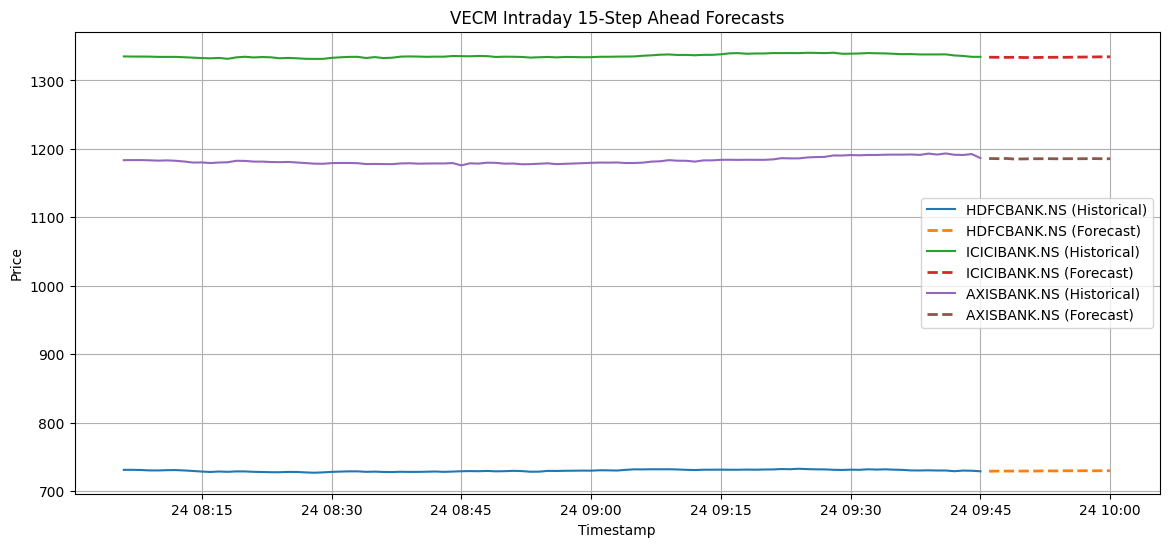

In [18]:
import numpy as np
import pandas as pd

# 1. Generate N-step ahead forecast
forecast_steps = 15
forecast_arr = vecm_res.predict(steps=forecast_steps)

# 2. Construct future timestamp index
last_timestamp = data.index[-1]
freq = pd.infer_freq(data.index) or "1min"
future_index = pd.date_range(
    start=last_timestamp, periods=forecast_steps + 1, freq=freq
)[1:]

# 3. Create DataFrame for forecasted prices
forecast_df = pd.DataFrame(
    forecast_arr, index=future_index, columns=data.columns
)

# 4. Calculate expected price change summary
current_prices = data.iloc[-1]
final_forecast_prices = forecast_df.iloc[-1]
price_diff = final_forecast_prices - current_prices
pct_change = (price_diff / current_prices) * 100

summary_df = pd.DataFrame(
    {
        "Current Price": current_prices,
        f"Forecast Price (+{forecast_steps} steps)": final_forecast_prices,
        "Expected Change": price_diff,
        "% Change": pct_change,
    }
)

# --- OUTPUT 1: PRINT EXACT PREDICTED VALUES FOR EACH STEP ---
print("==================================================")
print(f"   STEP-BY-STEP FORECASTED VALUES (Next {forecast_steps} Periods)")
print("==================================================")
print(forecast_df.round(6))

# --- OUTPUT 2: PRINT SUMMARY COMPARISON TABLE ---
print("\n==================================================")
print("             FORECAST SUMMARY TABLE")
print("==================================================")
print(summary_df.round(6))

# --- OUTPUT 3: PLOT HISTORICAL DATA + FORECAST ---
plt.figure(figsize=(14, 6))
for col in data.columns:
    hist = data[col].iloc[-100:]  # Plot last 100 periods
    plt.plot(hist.index, hist.values, label=f"{col} (Historical)")
    plt.plot(
        forecast_df.index,
        forecast_df[col].values,
        "--",
        linewidth=2,
        label=f"{col} (Forecast)",
    )

plt.title(f"VECM Intraday {forecast_steps}-Step Ahead Forecasts")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()